<a href="https://colab.research.google.com/github/sudharsanselvan/ML_Classification-Regression_Projects/blob/main/chronic_class.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
df_data=pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Classification Project/kidney_disease.csv')

In [ ]:
df_data

,id,age,bp,sg,al,su,rbc,pc,pcc,ba,...,pcv,wc,rc,htn,dm,cad,appet,pe,ane,classification
0,0,48.0,80.0,1.020,1.0,0.0,NaN,normal,notpresent,notpresent,...,44,7800,5.2,yes,yes,no,good,no,no,ckd
1,1,7.0,50.0,1.020,4.0,0.0,NaN,normal,notpresent,notpresent,...,38,6000,NaN,no,no,no,good,no,no,ckd
2,2,62.0,80.0,1.010,2.0,3.0,normal,normal,notpresent,notpresent,...,31,7500,NaN,no,yes,no,poor,no,yes,ckd
3,3,48.0,70.0,1.005,4.0,0.0,normal,abnormal,present,notpresent,...,32,6700,3.9,yes,no,no,poor,yes,yes,ckd
4,4,51.0,80.0,1.010,2.0,0.0,normal,normal,notpresent,notpresent,...,35,7300,4.6,no,no,no,good,no,no,ckd
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
395,395,55.0,80.0,1.020,0.0,0.0,normal,normal,notpresent,notpresent,...,47,6700,4.9,no,no,no,good,no,no,notckd
396,396,42.0,70.0,1.025,0.0,0.0,normal,normal,notpresent,notpresent,...,54,7800,6.2,no,no,no,good,no,no,notckd
397,397,12.0,80.0,1.020,0.0,0.0,normal,normal,notpresent,notpresent,...,49,6600,5.4,no,no,no,good,no,no,notckd
398,398,17.0,60.0,1.025,0.0,0.0,normal,normal,notpresent,notpresent,...,51,7200,5.9,no,no,no,good,no,no,notckd


In [ ]:
df_data.shape

(400, 26)

In [ ]:
df_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 26 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   id              400 non-null    int64  
 1   age             391 non-null    float64
 2   bp              388 non-null    float64
 3   sg              353 non-null    float64
 4   al              354 non-null    float64
 5   su              351 non-null    float64
 6   rbc             248 non-null    object 
 7   pc              335 non-null    object 
 8   pcc             396 non-null    object 
 9   ba              396 non-null    object 
 10  bgr             356 non-null    float64
 11  bu              381 non-null    float64
 12  sc              383 non-null    float64
 13  sod             313 non-null    float64
 14  pot             312 non-null    float64
 15  hemo            348 non-null    float64
 16  pcv             330 non-null    object 
 17  wc              295 non-null    obj

In [ ]:
df_data.head()

,id,age,bp,sg,al,su,rbc,pc,pcc,ba,...,pcv,wc,rc,htn,dm,cad,appet,pe,ane,classification
0,0,48.0,80.0,1.020,1.0,0.0,NaN,normal,notpresent,notpresent,...,44,7800,5.2,yes,yes,no,good,no,no,ckd
1,1,7.0,50.0,1.020,4.0,0.0,NaN,normal,notpresent,notpresent,...,38,6000,NaN,no,no,no,good,no,no,ckd
2,2,62.0,80.0,1.010,2.0,3.0,normal,normal,notpresent,notpresent,...,31,7500,NaN,no,yes,no,poor,no,yes,ckd
3,3,48.0,70.0,1.005,4.0,0.0,normal,abnormal,present,notpresent,...,32,6700,3.9,yes,no,no,poor,yes,yes,ckd
4,4,51.0,80.0,1.010,2.0,0.0,normal,normal,notpresent,notpresent,...,35,7300,4.6,no,no,no,good,no,no,ckd


In [ ]:
df_data.drop('id',axis=1,inplace=True)

In [ ]:
df_data.head(20)

,age,bp,sg,al,su,rbc,pc,pcc,ba,bgr,...,pcv,wc,rc,htn,dm,cad,appet,pe,ane,classification
0,48.0,80.0,1.020,1.0,0.0,NaN,normal,notpresent,notpresent,121.0,...,44,7800,5.2,yes,yes,no,good,no,no,ckd
1,7.0,50.0,1.020,4.0,0.0,NaN,normal,notpresent,notpresent,NaN,...,38,6000,NaN,no,no,no,good,no,no,ckd
2,62.0,80.0,1.010,2.0,3.0,normal,normal,notpresent,notpresent,423.0,...,31,7500,NaN,no,yes,no,poor,no,yes,ckd
3,48.0,70.0,1.005,4.0,0.0,normal,abnormal,present,notpresent,117.0,...,32,6700,3.9,yes,no,no,poor,yes,yes,ckd
4,51.0,80.0,1.010,2.0,0.0,normal,normal,notpresent,notpresent,106.0,...,35,7300,4.6,no,no,no,good,no,no,ckd
5,60.0,90.0,1.015,3.0,0.0,NaN,NaN,notpresent,notpresent,74.0,...,39,7800,4.4,yes,yes,no,good,yes,no,ckd
6,68.0,70.0,1.010,0.0,0.0,NaN,normal,notpresent,notpresent,100.0,...,36,NaN,NaN,no,no,no,good,no,no,ckd
7,24.0,NaN,1.015,2.0,4.0,normal,abnormal,notpresent,notpresent,410.0,...,44,6900,5,no,yes,no,good,yes,no,ckd
8,52.0,100.0,1.015,3.0,0.0,normal,abnormal,present,notpresent,138.0,...,33,9600,4.0,yes,yes,no,good,no,yes,ckd
9,53.0,90.0,1.020,2.0,0.0,abnormal,abnormal,present,notpresent,70.0,...,29,12100,3.7,yes,yes,no,poor,no,yes,ckd


In [ ]:
df_data.describe()

,age,bp,sg,al,su,bgr,bu,sc,sod,pot,hemo
count,391.000000,388.000000,353.000000,354.000000,351.000000,356.000000,381.000000,383.000000,313.000000,312.000000,348.000000
mean,51.483376,76.469072,1.017408,1.016949,0.450142,148.036517,57.425722,3.072454,137.528754,4.627244,12.526437
std,17.169714,13.683637,0.005717,1.352679,1.099191,79.281714,50.503006,5.741126,10.408752,3.193904,2.912587
min,2.000000,50.000000,1.005000,0.000000,0.000000,22.000000,1.500000,0.400000,4.500000,2.500000,3.100000
25%,42.000000,70.000000,1.010000,0.000000,0.000000,99.000000,27.000000,0.900000,135.000000,3.800000,10.300000
50%,55.000000,80.000000,1.020000,0.000000,0.000000,121.000000,42.000000,1.300000,138.000000,4.400000,12.650000
75%,64.500000,80.000000,1.020000,2.000000,0.000000,163.000000,66.000000,2.800000,142.000000,4.900000,15.000000
max,90.000000,180.000000,1.025000,5.000000,5.000000,490.000000,391.000000,76.000000,163.000000,47.000000,17.800000


In [ ]:
df_data.columns=['Age','Blood_Pressure','Specific_Gravity','Albumin','Sugar','Red_Blood_Cells','Pus_Cell',
                 'Pus_Cell_Clumps','Bacteria','Blood_Glucose_Random','Blood_Urea','Serum_Creatinine','Sodium',
                 'Potassium','Haemoglobin','Packed_Cell_Volume','White_Blood_Cell_Count','Red_Blood_Cell_Count',
                 'Hypertension','Diabetes_Mellitus','Coronary_Artery_Disease','Appetite','Peda_Edema','Anemia','class']

In [ ]:
df_data.head()

,Age,Blood_Pressure,Specific_Gravity,Albumin,Sugar,Red_Blood_Cells,Pus_Cell,Pus_Cell_Clumps,Bacteria,Blood_Glucose_Random,...,Packed_Cell_Volume,White_Blood_Cell_Count,Red_Blood_Cell_Count,Hypertension,Diabetes_Mellitus,Coronary_Artery_Disease,Appetite,Peda_Edema,Anemia,class
0,48.0,80.0,1.020,1.0,0.0,NaN,normal,notpresent,notpresent,121.0,...,44,7800,5.2,yes,yes,no,good,no,no,ckd
1,7.0,50.0,1.020,4.0,0.0,NaN,normal,notpresent,notpresent,NaN,...,38,6000,NaN,no,no,no,good,no,no,ckd
2,62.0,80.0,1.010,2.0,3.0,normal,normal,notpresent,notpresent,423.0,...,31,7500,NaN,no,yes,no,poor,no,yes,ckd
3,48.0,70.0,1.005,4.0,0.0,normal,abnormal,present,notpresent,117.0,...,32,6700,3.9,yes,no,no,poor,yes,yes,ckd
4,51.0,80.0,1.010,2.0,0.0,normal,normal,notpresent,notpresent,106.0,...,35,7300,4.6,no,no,no,good,no,no,ckd


In [ ]:
text_columns=['Packed_Cell_Volume','White_Blood_Cell_Count','Red_Blood_Cell_Count']
for i in text_columns:
    print(f"{i}: {df_data[i].dtype}")

Packed_Cell_Volume: object
White_Blood_Cell_Count: object
Red_Blood_Cell_Count: object


In [ ]:
#Change into numeric columns

In [ ]:
def convert_text_to_numeric(df_data, column):
    df_data[column]=pd.to_numeric(df_data[column], errors='coerce')

for column in text_columns:
    convert_text_to_numeric(df_data, column)
    print(f"{column} : {df_data[column].dtype}")


Packed_Cell_Volume : float64
White_Blood_Cell_Count : float64
Red_Blood_Cell_Count : float64


In [ ]:
#Handling Missing Values

In [ ]:
missing=df_data.isnull().sum()
missing[missing>0].sort_values(ascending=False)

,0
Red_Blood_Cells,152
Red_Blood_Cell_Count,131
White_Blood_Cell_Count,106
Potassium,88
Sodium,87
Packed_Cell_Volume,71
Pus_Cell,65
Haemoglobin,52
Sugar,49
Specific_Gravity,47


In [ ]:
def mean_value_imputation(df_data,column):
    mean_value=df_data[column].mean()
    df_data[column].fillna(value=mean_value,inplace=True)

def mode_value_imputation(df_data,column):
    mode=df_data[column].mode()[0]
    df_data[column]=df_data[column].fillna(mode)

In [ ]:
df_data.columns

Index(['Age', 'Blood_Pressure', 'Specific_Gravity', 'Albumin', 'Sugar',
       'Red_Blood_Cells', 'Pus_Cell', 'Pus_Cell_Clumps', 'Bacteria',
       'Blood_Glucose_Random', 'Blood_Urea', 'Serum_Creatinine', 'Sodium',
       'Potassium', 'Haemoglobin', 'Packed_Cell_Volume',
       'White_Blood_Cell_Count', 'Red_Blood_Cell_Count', 'Hypertension',
       'Diabetes_Mellitus', 'Coronary_Artery_Disease', 'Appetite',
       'Peda_Edema', 'Anemia', 'class'],
      dtype='object')

In [ ]:
num_cols=[col for col in df_data.columns if df_data[col].dtype!='object']

for col_name in num_cols:
    mean_value=df_data[col_name].mean()
    df_data.loc[:, col_name] = df_data.loc[:, col_name].fillna(value=mean_value)

In [ ]:
cat_cols=[col for col in df_data.columns if df_data[col].dtype=='object']

for col_name in cat_cols:
    mode_value_imputation(df_data, col_name)

In [ ]:
missing=df_data.isnull().sum()
missing[missing>0].sort_values(ascending=False)

,0


In [ ]:
df_data.head()

,Age,Blood_Pressure,Specific_Gravity,Albumin,Sugar,Red_Blood_Cells,Pus_Cell,Pus_Cell_Clumps,Bacteria,Blood_Glucose_Random,...,Packed_Cell_Volume,White_Blood_Cell_Count,Red_Blood_Cell_Count,Hypertension,Diabetes_Mellitus,Coronary_Artery_Disease,Appetite,Peda_Edema,Anemia,class
0,48.0,80.0,1.020,1.0,0.0,normal,normal,notpresent,notpresent,121.000000,...,44.0,7800.0,5.200000,yes,yes,no,good,no,no,ckd
1,7.0,50.0,1.020,4.0,0.0,normal,normal,notpresent,notpresent,148.036517,...,38.0,6000.0,4.707435,no,no,no,good,no,no,ckd
2,62.0,80.0,1.010,2.0,3.0,normal,normal,notpresent,notpresent,423.000000,...,31.0,7500.0,4.707435,no,yes,no,poor,no,yes,ckd
3,48.0,70.0,1.005,4.0,0.0,normal,abnormal,present,notpresent,117.000000,...,32.0,6700.0,3.900000,yes,no,no,poor,yes,yes,ckd
4,51.0,80.0,1.010,2.0,0.0,normal,normal,notpresent,notpresent,106.000000,...,35.0,7300.0,4.600000,no,no,no,good,no,no,ckd


In [ ]:
print(f"Diabetes_Mellitus: {df_data['Diabetes_Mellitus'].unique()}")
print(f"Coronary_Artery_Disease: {df_data['Coronary_Artery_Disease'].unique()}")
print(f"class: {df_data['class'].unique()}")

Diabetes_Mellitus: ['yes' 'no' ' yes' '\tno' '\tyes']
Coronary_Artery_Disease: ['no' 'yes' '\tno']
class: ['ckd' 'ckd\t' 'notckd']


In [ ]:
#Replace incorrect data

In [ ]:
df_data['Diabetes_Mellitus']=df_data['Diabetes_Mellitus'].replace(to_replace={' yes':'yes','\tno':'no','\tyes':'yes'})
df_data['Coronary_Artery_Disease']=df_data['Coronary_Artery_Disease'].replace(to_replace='\tno', value='no')
df_data['class']=df_data['class'].replace(to_replace={'ckd\t':'ckd','notckd':'not ckd'})

In [ ]:
print(f"Diabetes_Mellitus: {df_data['Diabetes_Mellitus'].unique()}")
print(f"Coronary_Artery_Disease: {df_data['Coronary_Artery_Disease'].unique()}")
print(f"class: {df_data['class'].unique()}")

Diabetes_Mellitus: ['yes' 'no']
Coronary_Artery_Disease: ['no' 'yes']
class: ['ckd' 'not ckd']


In [ ]:
df_data['class']=df_data['class'].map({'ckd':1, 'not ckd':0})
df_data['Red_Blood_Cells']=df_data['Red_Blood_Cells'].map({'normal':1, 'abnormal':0})
df_data['Pus_Cell']=df_data['Pus_Cell'].map({'normal':1, 'abnormal':0})
df_data['Pus_Cell_Clumps']=df_data['Pus_Cell_Clumps'].map({'present':1, 'nonpresent':0})
df_data['Bacteria']=df_data['Bacteria'].map({'present':1, 'nonpresent':0})
df_data['Hypertension']=df_data['Hypertension'].map({'yes':1, 'no':0})
df_data['Diabetes_Mellitus']=df_data['Diabetes_Mellitus'].map({'yes':1, 'no':0})
df_data['Coronary_Artery_Disease']=df_data['Coronary_Artery_Disease'].map({'yes':1, 'no':0})
df_data['Appetite']=df_data['Appetite'].map({'good':1, 'poor':0})
df_data['Peda_Edema']=df_data['Peda_Edema'].map({'yes':1, 'no':0})
df_data['Anemia']=df_data['Anemia'].map({'yes':1, 'no':0})

In [ ]:
df_data.head(5)

,Age,Blood_Pressure,Specific_Gravity,Albumin,Sugar,Red_Blood_Cells,Pus_Cell,Pus_Cell_Clumps,Bacteria,Blood_Glucose_Random,...,Packed_Cell_Volume,White_Blood_Cell_Count,Red_Blood_Cell_Count,Hypertension,Diabetes_Mellitus,Coronary_Artery_Disease,Appetite,Peda_Edema,Anemia,class
0,48.0,80.0,1.020,1.0,0.0,1,1,NaN,NaN,121.000000,...,44.0,7800.0,5.200000,1,1,0,1,0,0,1
1,7.0,50.0,1.020,4.0,0.0,1,1,NaN,NaN,148.036517,...,38.0,6000.0,4.707435,0,0,0,1,0,0,1
2,62.0,80.0,1.010,2.0,3.0,1,1,NaN,NaN,423.000000,...,31.0,7500.0,4.707435,0,1,0,0,0,1,1
3,48.0,70.0,1.005,4.0,0.0,1,0,1.0,NaN,117.000000,...,32.0,6700.0,3.900000,1,0,0,0,1,1,1
4,51.0,80.0,1.010,2.0,0.0,1,1,NaN,NaN,106.000000,...,35.0,7300.0,4.600000,0,0,0,1,0,0,1


In [ ]:
########################################
df_data.fillna(0, inplace=True)

In [ ]:
df_data.head(5)

,Age,Blood_Pressure,Specific_Gravity,Albumin,Sugar,Red_Blood_Cells,Pus_Cell,Pus_Cell_Clumps,Bacteria,Blood_Glucose_Random,...,Packed_Cell_Volume,White_Blood_Cell_Count,Red_Blood_Cell_Count,Hypertension,Diabetes_Mellitus,Coronary_Artery_Disease,Appetite,Peda_Edema,Anemia,class
0,48.0,80.0,1.020,1.0,0.0,1,1,0.0,0.0,121.000000,...,44.0,7800.0,5.200000,1,1,0,1,0,0,1
1,7.0,50.0,1.020,4.0,0.0,1,1,0.0,0.0,148.036517,...,38.0,6000.0,4.707435,0,0,0,1,0,0,1
2,62.0,80.0,1.010,2.0,3.0,1,1,0.0,0.0,423.000000,...,31.0,7500.0,4.707435,0,1,0,0,0,1,1
3,48.0,70.0,1.005,4.0,0.0,1,0,1.0,0.0,117.000000,...,32.0,6700.0,3.900000,1,0,0,0,1,1,1
4,51.0,80.0,1.010,2.0,0.0,1,1,0.0,0.0,106.000000,...,35.0,7300.0,4.600000,0,0,0,1,0,0,1


In [ ]:
%pip install seaborn

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

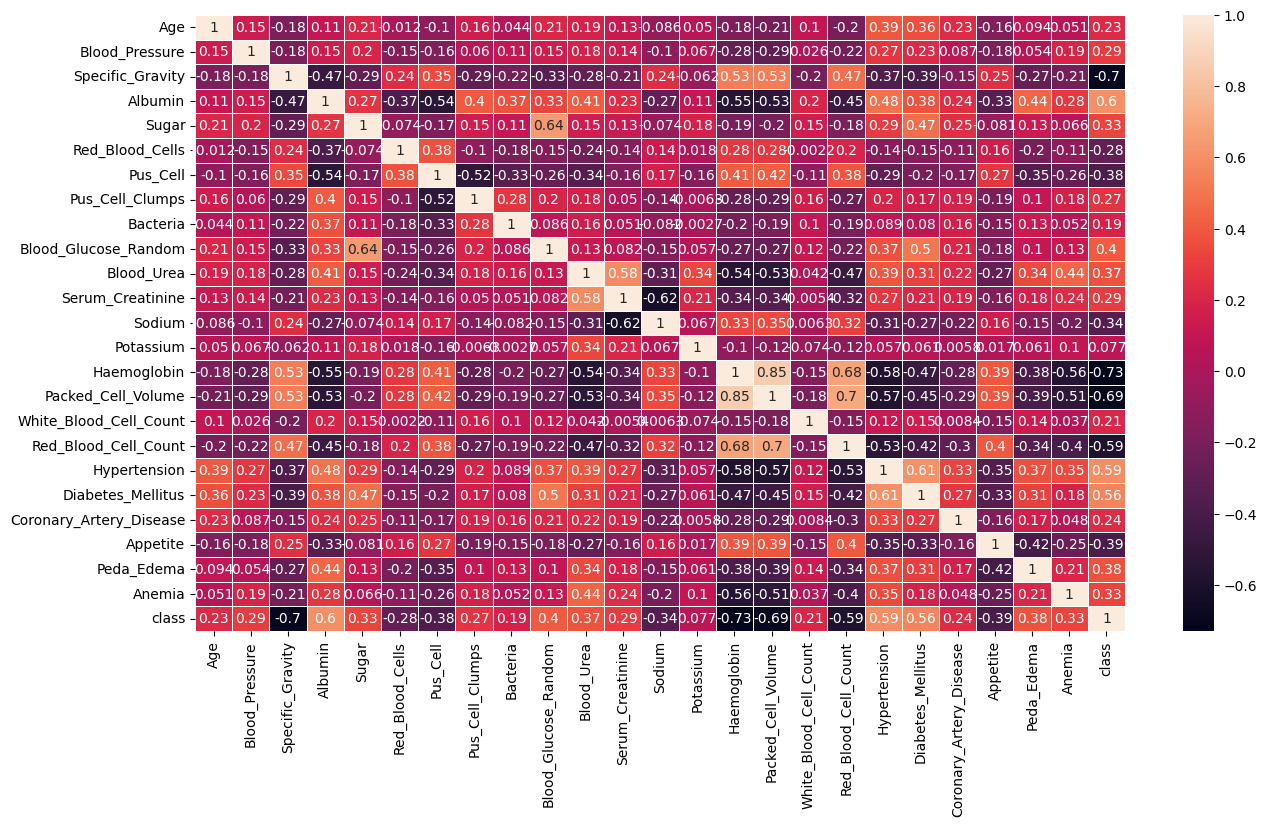

In [ ]:
plt.figure(figsize=(15,8))
sns.heatmap(df_data.corr(), annot=True, linewidths= 0.5)
plt.show()

In [ ]:
target_corr=df_data.corr()['Age'].abs().sort_values(ascending=False)[1:]
target_corr

,Age
Hypertension,0.393440
Diabetes_Mellitus,0.363475
Coronary_Artery_Disease,0.232951
class,0.225405
Blood_Glucose_Random,0.214410
Packed_Cell_Volume,0.211805
Sugar,0.207857
Red_Blood_Cell_Count,0.201051
Blood_Urea,0.187544
Specific_Gravity,0.180570


In [ ]:
df_data['class'].value_counts()

,count
class,
1,250
0,150


In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
x=df_data.drop('class',axis=1)
y=df_data['class']

x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.25,random_state=25)
print(f"'x' Shape: {x_test.shape}")
print(f"'y' Shape: {y_test.shape}")

'x' Shape: (100, 24)
'y' Shape: (100,)


In [ ]:
#Machine_Learning_Algorithm

In [ ]:
from sklearn.tree import DecisionTreeClassifier

dct=DecisionTreeClassifier()
dct.fit(x_train,y_train)

DecisionTreeClassifier()

In [ ]:
y_pred_dct=dct.predict(x_test)
y_pred_dct

array([1, 1, 0, 0, 0, 0, 1, 0, 0, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 0, 0,
       0, 1, 0, 1, 0, 0, 1, 0, 1, 1, 0, 1, 1, 1, 0, 1, 0, 0, 1, 0, 0, 1,
       1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1,
       1, 0, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 0, 1, 0, 1, 1, 1, 1, 1,
       1, 0, 0, 1, 0, 1, 1, 1, 0, 1, 1, 1])

In [ ]:
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

In [ ]:
models = []
models.append(('Naive Bayes',GaussianNB()))
models.append(('KNN',KNeighborsClassifier(n_neighbors=8)))
models.append(('Random Forest',RandomForestClassifier()))
models.append(('Decision Tree',DecisionTreeClassifier()))
models.append(('SVM',SVC(kernel='linear')))

In [ ]:
#import all metrics

In [ ]:
from sklearn.metrics import accuracy_score,precision_score,recall_score,confusion_matrix,f1_score,classification_report

In [ ]:
for name,model in models:
    print(name,model)
    print()
    model.fit(x_train,y_train)
    y_pred=model.predict(x_test)
    print(confusion_matrix(y_test,y_pred))
    print('\n')
    print("accuracy: ",accuracy_score(y_test,y_pred))
    print('\n')
    print("Precision: ",precision_score(y_test,y_pred))
    print('\n')
    print("recall: ",recall_score(y_test,y_pred))
    print('\n')
    print("f1score: ",f1_score(y_test,y_pred))
    print('\n')

Naive Bayes GaussianNB()

[[37  0]
 [ 5 58]]


accuracy:  0.95


Precision:  1.0


recall:  0.9206349206349206


f1score:  0.9586776859504132


KNN KNeighborsClassifier(n_neighbors=8)

[[31  6]
 [18 45]]


accuracy:  0.76


Precision:  0.8823529411764706


recall:  0.7142857142857143


f1score:  0.7894736842105263


Random Forest RandomForestClassifier()

[[35  2]
 [ 0 63]]


accuracy:  0.98


Precision:  0.9692307692307692


recall:  1.0


f1score:  0.984375


Decision Tree DecisionTreeClassifier()

[[35  2]
 [ 1 62]]


accuracy:  0.97


Precision:  0.96875


recall:  0.9841269841269841


f1score:  0.9763779527559056


SVM SVC(kernel='linear')

[[34  3]
 [ 2 61]]


accuracy:  0.95


Precision:  0.953125


recall:  0.9682539682539683


f1score:  0.9606299212598425


